In [4]:
import os
from google.cloud import bigquery


# 1. Configura la ruta a tus credenciales de Google Cloud
# REEMPLAZA ESTA RUTA por el camino exacto donde guardaste tu archivo JSON en tu compu
ruta_json = "/Users/nato/Desktop/Data Projects/Python/temporal-bongo-499004-s9-267e5c60e9de.json" 
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = ruta_json

# 2. Ahora sí, inicializar el cliente (ya va a encontrar las llaves automáticamente)
client = bigquery.Client()

# 3. Tu consulta SQL (Acentos graves)
query = """
    SELECT 
    product_type,
    Price,
    Availability,
    number_products_sold,
    revenue_generated,
    customer_demographics,
    stock_levels,
    lead_times,
    order_quantities,
    shipping_times,
    shipping_carriers,
    shipping_costs,
    supplier_name,
    Location,
    lead_time,
    production_volumes,
    manufacturing_lead_time,
    FROM `temporal-bongo-499004-s9.Proyecto_Supply_Chain.supply_chain`
    LIMIT 10
"""

# Ejecutar y mostrar resultados
print("Conectando y ejecutando la consulta...")
query_job = client.query(query)
rows = query_job.result()

print("\n--- Resultados del Pipeline ---")
for row in rows:
    print(f"Producto: {row['product_type']} | Availability: {row['Availability']} | Stock: {row['stock_levels']} | Lead Time: {row['lead_times']} días")

Conectando y ejecutando la consulta...

--- Resultados del Pipeline ---
Producto: skincare | Availability: 26 | Stock: 5 | Lead Time: 3 días
Producto: skincare | Availability: 22 | Stock: 27 | Lead Time: 12 días
Producto: skincare | Availability: 96 | Stock: 1 | Lead Time: 26 días
Producto: cosmetics | Availability: 88 | Stock: 57 | Lead Time: 29 días
Producto: skincare | Availability: 35 | Stock: 14 | Lead Time: 27 días
Producto: skincare | Availability: 95 | Stock: 46 | Lead Time: 23 días
Producto: skincare | Availability: 26 | Stock: 78 | Lead Time: 29 días
Producto: cosmetics | Availability: 91 | Stock: 31 | Lead Time: 23 días
Producto: haircare | Availability: 16 | Stock: 97 | Lead Time: 11 días
Producto: cosmetics | Availability: 14 | Stock: 76 | Lead Time: 2 días


In [5]:
import matplotlib.pyplot as plt


In [6]:
import os
import pandas as pd
from google.cloud import bigquery

# 1. Configurar credenciales
ruta_json = "/Users/nato/Desktop/Data Projects/Python/temporal-bongo-499004-s9-267e5c60e9de.json" 
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = ruta_json

client = bigquery.Client()

print("Conexión establecida. Ejecutando análisis macro...")

Conexión establecida. Ejecutando análisis macro...


In [7]:
query_productos = """
    SELECT 
        product_type,
        ROUND(AVG(price), 2) AS average_price,
        SUM(availability) AS total_availability,
        SUM(number_products_sold) AS total_products_sold,
        ROUND(SUM(revenue_generated), 2) AS total_revenue
    FROM `temporal-bongo-499004-s9.Proyecto_Supply_Chain.supply_chain`
    GROUP BY product_type
    ORDER BY total_revenue DESC
"""

# Ejecutar y convertir a DataFrame
df_productos = client.query(query_productos).to_dataframe()

# Desplegar la tabla interactiva en el notebook
df_productos

/opt/anaconda3/envs/demo/lib/python3.13/site-packages/google/cloud/bigquery/table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,product_type,average_price,total_availability,total_products_sold,total_revenue
0,skincare,47.26,2037,20731,241628.16
1,haircare,46.01,1471,13611,174455.39
2,cosmetics,57.36,1332,11757,161521.27


In [8]:
query_inventory = """
    SELECT
        `product_type` AS product_type,
        ROUND(AVG(`number_products_sold` / NULLIF(Availability, 0)), 4) AS sell_through_rate,
        SUM(`stock_levels`) AS total_stock_levels
    FROM `temporal-bongo-499004-s9.Proyecto_Supply_Chain.supply_chain`
    GROUP BY `product_type`
    ORDER BY sell_through_rate DESC
"""

df_inventory = client.query(query_inventory).to_dataframe()
df_inventory

/opt/anaconda3/envs/demo/lib/python3.13/site-packages/google/cloud/bigquery/table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,product_type,sell_through_rate,total_stock_levels
0,skincare,39.4957,1608
1,haircare,18.4608,1644
2,cosmetics,15.4585,1525


In [9]:
query_demographics = """
    SELECT
        `customer_demographics` AS customer_gender,
        SUM(`Number_products_sold`) AS total_products_sold,
        ROUND(SUM(`revenue_generated`), 2) AS total_revenue
    FROM `temporal-bongo-499004-s9.Proyecto_Supply_Chain.supply_chain`
    GROUP BY `customer_demographics`
    ORDER BY total_revenue DESC
"""

df_demographics = client.query(query_demographics).to_dataframe()
df_demographics

/opt/anaconda3/envs/demo/lib/python3.13/site-packages/google/cloud/bigquery/table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,customer_gender,total_products_sold,total_revenue
0,Unknown,15211,173090.13
1,Female,12801,161514.49
2,Male,7507,126634.39
3,Non-binary,10580,116365.80


In [10]:
# Query Avanzada: Diagnóstico de Overstock y Cuellos de Botella Operativos
query_overstock = """
    SELECT 
        product_type,
        ROUND(AVG(stock_levels), 2) AS avg_stock_levels,
        ROUND(AVG(number_products_sold), 2) AS avg_products_sold,
        ROUND(AVG(production_volumes), 2) AS avg_production_volume,
        ROUND(AVG(lead_time), 2) AS avg_production_lead_time,
        ROUND(AVG(stock_levels / NULLIF(number_products_sold, 0)), 2) AS stock_to_sales_ratio
    FROM `temporal-bongo-499004-s9.Proyecto_Supply_Chain.supply_chain`
    GROUP BY product_type
    ORDER BY stock_to_sales_ratio DESC
"""

print("Ejecutando diagnóstico de Supply Chain...")
df_overstock = client.query(query_overstock).to_dataframe()
df_overstock



Ejecutando diagnóstico de Supply Chain...


/opt/anaconda3/envs/demo/lib/python3.13/site-packages/google/cloud/bigquery/table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,product_type,avg_stock_levels,avg_products_sold,avg_production_volume,avg_production_lead_time,stock_to_sales_ratio
0,haircare,48.35,400.32,586.97,18.71,0.33
1,cosmetics,58.65,452.19,479.27,13.54,0.21
2,skincare,40.20,518.27,609.15,18.00,0.13


In [11]:
query_skus_criticos = """
    SELECT 
        sku,
        product_type,
        stock_levels,
        number_products_sold,
        production_volumes,
        manufacturing_lead_time,
        (stock_levels - number_products_sold) AS excess_stock
    FROM `temporal-bongo-499004-s9.Proyecto_Supply_Chain.supply_chain`
    WHERE product_type = 'haircare'
    ORDER BY excess_stock DESC
    LIMIT 10
"""

df_criticos = client.query(query_skus_criticos).to_dataframe()
df_criticos

/opt/anaconda3/envs/demo/lib/python3.13/site-packages/google/cloud/bigquery/table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,sku,product_type,stock_levels,number_products_sold,production_volumes,manufacturing_lead_time,excess_stock
0,SKU45,haircare,93,24,794,25,69
1,SKU48,haircare,30,29,109,18,1
2,SKU2,haircare,1,8,971,27,-7
3,SKU97,haircare,46,62,535,13,-16
4,SKU70,haircare,10,32,775,16,-22
5,SKU93,haircare,63,114,824,20,-51
6,SKU51,haircare,100,154,673,28,-54
7,SKU5,haircare,90,147,104,17,-57
8,SKU25,haircare,82,142,934,23,-60
9,SKU87,haircare,5,79,523,17,-74


In [12]:
query_health_check = """
    SELECT 
        sku,
        `product_type` AS product_type,
        `stock_levels` AS stock_levels,
        `number_products_sold` AS products_sold,
        `order_quantities` AS order_quantities,
        `lead_time` AS lead_time,
        -- Regla lógica para clasificar el estado del inventario
        CASE 
            WHEN `stock_levels` < `order_quantities` THEN 'Riesgo de Desabasto (Understock)'
            WHEN `stock_levels` > (`number_products_sold` * 1.5) THEN 'Sobreinventario (Overstock)'
            ELSE 'Inventario Saludable (Healthy)'
        END AS inventory_status
    FROM `temporal-bongo-499004-s9.Proyecto_Supply_Chain.supply_chain`
    ORDER BY `stock_levels` ASC
"""

print("Clasificando la salud del inventario...")
df_health = client.query(query_health_check).to_dataframe()

# Vamos a ver cuántos productos caen en cada categoría
print("\n--- Resumen de Salud del Almacén ---")
print(df_health['inventory_status'].value_counts())

# Desplegar la tabla completa
df_health.head(15)

Clasificando la salud del inventario...


/opt/anaconda3/envs/demo/lib/python3.13/site-packages/google/cloud/bigquery/table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(



--- Resumen de Salud del Almacén ---
inventory_status
Riesgo de Desabasto (Understock)    54
Inventario Saludable (Healthy)      45
Sobreinventario (Overstock)          1
Name: count, dtype: int64


,sku,product_type,stock_levels,products_sold,order_quantities,lead_time,inventory_status
0,SKU68,haircare,0,163,58,2,Riesgo de Desabasto (Understock)
1,SKU34,skincare,1,602,21,4,Riesgo de Desabasto (Understock)
2,SKU2,haircare,1,8,88,12,Riesgo de Desabasto (Understock)
3,SKU16,skincare,2,280,78,3,Riesgo de Desabasto (Understock)
4,SKU33,cosmetics,4,616,95,1,Riesgo de Desabasto (Understock)
5,SKU24,haircare,4,209,2,28,Inventario Saludable (Healthy)
6,SKU47,skincare,4,910,51,10,Riesgo de Desabasto (Understock)
7,SKU8,cosmetics,5,150,15,13,Riesgo de Desabasto (Understock)
8,SKU78,haircare,5,946,51,25,Riesgo de Desabasto (Understock)
9,SKU4,skincare,5,871,56,5,Riesgo de Desabasto (Understock)


In [13]:
# Query a prueba de balas usando SUM(CASE WHEN)
query_matriz_riesgo = """
    SELECT 
        product_type,
        -- Contamos riesgo de desabasto
        SUM(CASE WHEN stock_levels < order_quantities THEN 1 ELSE 0 END) AS understock_risk_count,
        
        -- Contamos sobreinventario
        SUM(CASE WHEN stock_levels > (number_products_sold * 1.5) THEN 1 ELSE 0 END) AS overstock_count,
        
        -- Contamos nivel saludable
        SUM(CASE WHEN stock_levels >= order_quantities AND stock_levels <= (number_products_sold * 1.5) THEN 1 ELSE 0 END) AS healthy_count,
        
        -- Total de SKUs
        COUNT(*) AS total_skus
    FROM `temporal-bongo-499004-s9.Proyecto_Supply_Chain.supply_chain`
    GROUP BY product_type
    ORDER BY understock_risk_count DESC
"""

print("Generando matriz de riesgo por categoría...")
df_matriz = client.query(query_matriz_riesgo).to_dataframe()

# Desplegar la tabla interactiva
df_matriz

Generando matriz de riesgo por categoría...


/opt/anaconda3/envs/demo/lib/python3.13/site-packages/google/cloud/bigquery/table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,product_type,understock_risk_count,overstock_count,healthy_count,total_skus
0,skincare,26,0,14,40
1,haircare,15,1,18,34
2,cosmetics,13,0,13,26


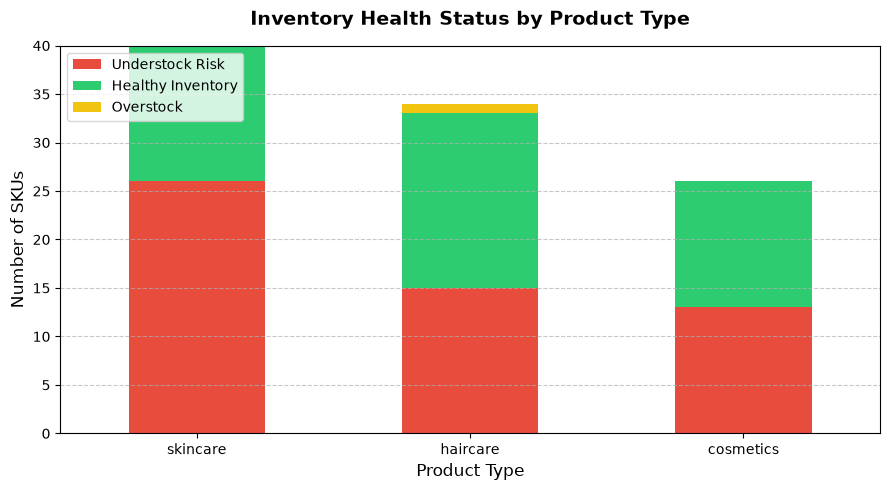

In [14]:
import matplotlib.pyplot as plt

# Configuramos la tabla para que sea la base del gráfico
df_plot = df_matriz.set_index('product_type')[['understock_risk_count', 'healthy_count', 'overstock_count']]

# Crear el gráfico de barras apiladas (Stacked Bar Chart)
ax = df_plot.plot(
    kind='bar', 
    stacked=True, 
    color=['#e74c3c', '#2ecc71', '#f1c40f'], # Rojo (Riesgo), Verde (Sano), Amarillo (Overstock)
    figsize=(9, 5)
)

# Detalles estéticos
plt.title('Inventory Health Status by Product Type', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Product Type', fontsize=12)
plt.ylabel('Number of SKUs', fontsize=12)
plt.xticks(rotation=0)
plt.legend(['Understock Risk', 'Healthy Inventory', 'Overstock'], loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()